![logo](../../.././docs/images/Logo_Destination_Earth_Colours.png)

# Lazy Browse — DestinE Climate DT Monthly Portfolio

This notebook provides an **instant xarray view** of DestinE Climate DT Generation 2 data.
Variables and coordinates appear immediately, actual data is fetched from the data bridge **only when you access values** (e.g. plotting, `.values`, `.compute()`).

**Prerequisites:** run `01_key_destine_once.ipynb` once to authenticate.

In [ ]:
import logging, warnings
import earthkit.data

# Disable earthkit disk cache (polytope_zarr caches decoded arrays in memory)
earthkit.data.config.set("cache-policy", "off")

# Silence verbose output from polytope / earthkit internals
for _ln in ("polytope", "polytope.api", "earthkit.data", "urllib3"):
    logging.getLogger(_ln).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
import numpy as np
import pandas as pd
from polytope_zarr import PolytopeZarrStore
from destine_portfolio import PORTFOLIO_GEN2_CLMN

## 1. Define the dataset

We declare which coordinates, variables, and Polytope request fields to use.
Nothing is downloaded here — the store just builds metadata.

In [ ]:
# ── Configuration ─────────────────────────────────────────────────

# ── Choose a levtype (uncomment one) ──────────────────────────────
LEVTYPE = "sfc"                    # 34 vars — surface atmosphere
# LEVTYPE = "pl"                   #  9 vars — pressure levels (19 levels, 1000–1 hPa)
# LEVTYPE = "hl"                   #  2 vars — height levels (100 m, IFS-only)
# LEVTYPE = "sol"                  #  2 vars — soil / snow (5 levels)
# LEVTYPE = "o2d"                  # 13 vars — 2-D ocean & sea ice
# LEVTYPE = "o3d"                  #  5 vars — 3-D ocean (up to 75 levels)

store = PolytopeZarrStore.from_climate_dt(
    models=["ICON", "IFS-FESOM", "IFS-NEMO"],
    experiment="hist", # 'cont', 'hist', 'SSP3-7.0'
    resolution="standard", # 'standard', 'high'
    levtype=LEVTYPE,
    years=range(1990, 2015), # 25-year historical period
)
print(store)

<PolytopeZarrStore 34 variables (time=300, cell=196608, model=3)>


## 2. Open as xarray Dataset

This is **instant** — no data downloaded yet. You see all variables,
dimensions, and coordinate values.

In [ ]:
ds = store.open()
ds

<xarray.Dataset> Size: 24GB
Dimensions:       (model: 3, time: 300, cell: 196608)
Coordinates:
  * model         (model) object 24B 'ICON' 'IFS-FESOM' 'IFS-NEMO'
  * time          (time) datetime64[ns] 2kB 1990-01-01 1990-02-01 ... 2014-12-01
  * cell          (cell) int32 786kB 0 1 2 3 4 ... 196604 196605 196606 196607
Data variables: (12/34)
    avg_10u       (model, time, cell) float32 708MB ...
    avg_10v       (model, time, cell) float32 708MB ...
    avg_10ws      (model, time, cell) float32 708MB ...
    avg_2d        (model, time, cell) float32 708MB ...
    avg_2t        (model, time, cell) float32 708MB ...
    avg_ie        (model, time, cell) float32 708MB ...
    ...            ...
    avg_tnlwrf    (model, time, cell) float32 708MB ...
    avg_tnlwrfcs  (model, time, cell) float32 708MB ...
    avg_tnswrf    (model, time, cell) float32 708MB ...
    avg_tnswrfcs  (model, time, cell) float32 708MB ...
    avg_tprate    (model, time, cell) float32 708MB ...
    avg_tsrwe     (model, time, cell) float32 708MB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 34 variables (time=300, cell=196608,...

## 3. Plot a single monthly field (triggers lazy fetch)

Only now does the store actually call Polytope — fetching data for the
selected model, time, and variable.

In [ ]:
import healpy as hp
import matplotlib.pyplot as plt

field = ds["avg_2t"].sel(model="IFS-FESOM", time="2010-06-01")
print(f"Fetching {dict(field.sizes)} values...")  # triggers the Polytope request
field_values = field.values

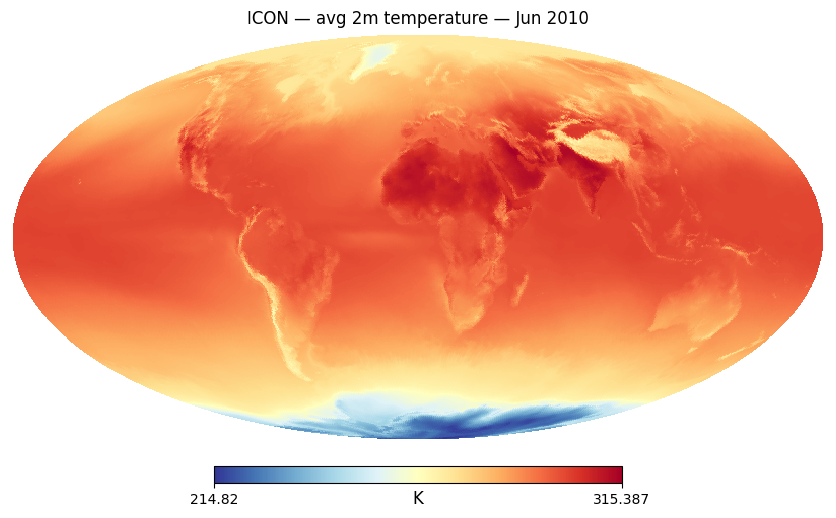

In [ ]:
hp.mollview(field_values, title="ICON — avg 2m temperature — Jun 2010",
            unit="K", cmap="RdYlBu_r", nest=True, flip='geo')
plt.show()

In [ ]:
#annual mean
field2 = ds["avg_tprate"].sel(model="IFS-FESOM", time=slice("2014-01", "2014-12")).mean("time")
field2_values = field2.values  # triggers the Polytope request

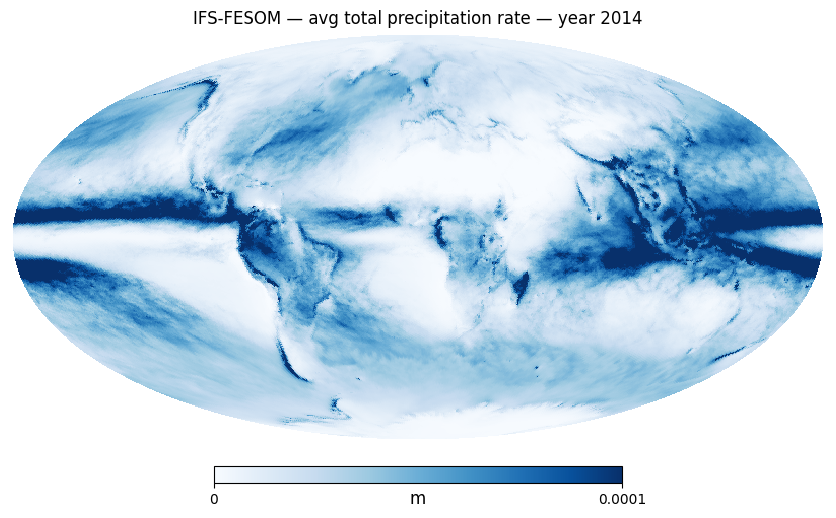

In [ ]:
hp.mollview(field2_values,
            title="IFS-FESOM — avg total precipitation rate — year 2014",
            unit="m", cmap="Blues", min=0, max=0.0001, nest=True, flip='geo')
plt.show()

## 4. Compare experiments: climate change signal

Create a second store for the scenario experiment, then take the difference to the historical.
`.polytope.sel()` automatically sets `batch_years` from the time slice so each call fetches all requested years in one Polytope request.

> **Note:** ICON scenario data is available to **2040**; IFS-NEMO/IFS-FESOM to **2049**.
> When slicing ICON scenario data, use `time=slice("2015-01", "2040-12")`.

In [ ]:
scen_store = PolytopeZarrStore.from_climate_dt(
    models=["ICON", "IFS-FESOM", "IFS-NEMO"],
    experiment="SSP3-7.0",
    levtype=LEVTYPE,
    years=range(2015, 2050),
)

ds_scen = scen_store.open()
ds_scen

<xarray.Dataset> Size: 34GB
Dimensions:       (model: 3, time: 420, cell: 196608)
Coordinates:
  * model         (model) object 24B 'ICON' 'IFS-FESOM' 'IFS-NEMO'
  * time          (time) datetime64[ns] 3kB 2015-01-01 2015-02-01 ... 2049-12-01
  * cell          (cell) int32 786kB 0 1 2 3 4 ... 196604 196605 196606 196607
Data variables: (12/34)
    avg_10u       (model, time, cell) float32 991MB ...
    avg_10v       (model, time, cell) float32 991MB ...
    avg_10ws      (model, time, cell) float32 991MB ...
    avg_2d        (model, time, cell) float32 991MB ...
    avg_2t        (model, time, cell) float32 991MB ...
    avg_ie        (model, time, cell) float32 991MB ...
    ...            ...
    avg_tnlwrf    (model, time, cell) float32 991MB ...
    avg_tnlwrfcs  (model, time, cell) float32 991MB ...
    avg_tnswrf    (model, time, cell) float32 991MB ...
    avg_tnswrfcs  (model, time, cell) float32 991MB ...
    avg_tprate    (model, time, cell) float32 991MB ...
    avg_tsrwe     (model, time, cell) float32 991MB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 34 variables (time=420, cell=196608,...

In [ ]:
# .polytope.sel() auto-sets the number of batched years from the time slice -> single request per period, instead of ~30 requests per period
hist_field = ds["avg_2t"].polytope.sel(model="IFS-FESOM", time=slice("1990-01", "2014-12"))
scen_field = ds_scen["avg_2t"].polytope.sel(model="IFS-FESOM", time=slice("2015-01", "2049-12"))

diff = scen_field.mean("time") - hist_field.mean("time")
diff_values = diff.values

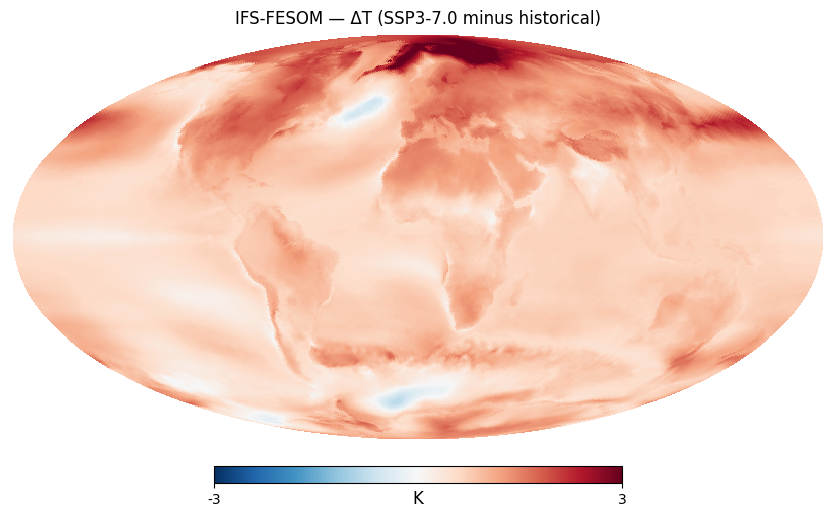

In [ ]:
hp.mollview(diff_values,
            title="IFS-FESOM — ΔT (SSP3-7.0 minus historical)",
            unit="K", cmap="RdBu_r", min=-3, max=3, nest=True, flip='geo')
plt.show()

# Server-side spatial subsetting (Polytope features)

`.polytope.sel()` also supports **server-side spatial extraction** via the
Polytope feature API.  Pass `bbox` or `polygon` to retrieve only a smaller subset of HEALPix cells, or `point` to get only a timeseries at a single point.

## Feature extraction — timeseries (monthly)

Monthly timeseries uses `point=(lat, lon)` and returns CoverageJSON.
The response contains time coordinates and field values that can be plotted directly.

> **See also:** [climate-dt-earthkit-fe-timeseries.ipynb](../feature-extraction/climate-dt-earthkit-fe-timeseries.ipynb) · [climate-dt-earthkit-fe-story-nudging.ipynb](../feature-extraction/climate-dt-earthkit-fe-story-nudging.ipynb) · [climate-dt-train-ai-timeseries-polytope.ipynb](../full-field-post-processing/climate-dt-train-ai-timeseries-polytope.ipynb)

In [ ]:
# Point timeseries — monthly (clmn stream)
ts_result = ds["avg_2t"].polytope.sel(
    model="IFS-FESOM",
    time=slice("2010-01", "2010-12"),
    point=(52.5, 13.4),  # Berlin
)

In [ ]:
print(type(ts_result))

<class 'dict'>


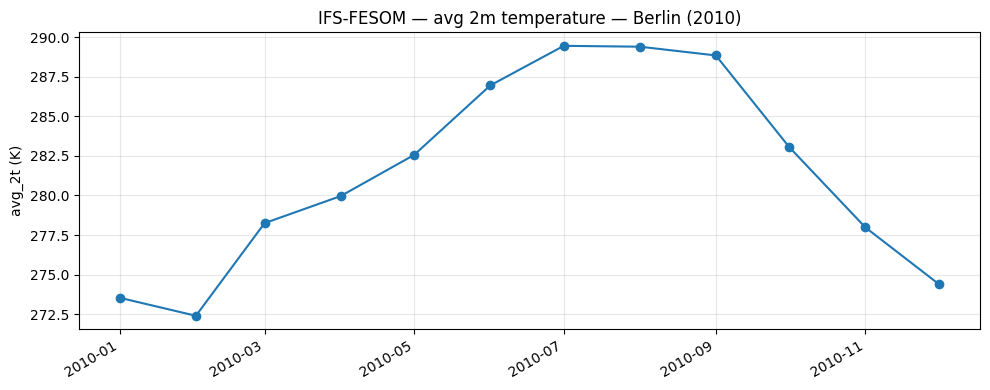

In [ ]:
import pandas as pd

# Extract times and values from CoverageJSON
cov = ts_result["coverages"][0]
times = pd.to_datetime(cov["domain"]["axes"]["t"]["values"])
values = cov["ranges"]["avg_2t"]["values"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times, values, marker="o")
ax.set_ylabel("avg_2t (K)")
ax.set_title("IFS-FESOM — avg 2m temperature — Berlin (2010)")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Feature extraction — bounding box (native HEALPix)

`bbox=(south, west, north, east)` returns native HEALPix pixels within the bounding box.
The cells below render them as filled polygons using `healpy.boundaries()` — no interpolation needed.

> **See also:** [climate-dt-earthkit-fe-boundingbox.ipynb](../feature-extraction/climate-dt-earthkit-fe-boundingbox.ipynb) · [climate-dt-earthkit-geotiff.ipynb](../full-field-post-processing/climate-dt-earthkit-geotiff.ipynb) (bbox → GeoTIFF)

Let's create a high-resolution store with the same parameters, but resolution="high". This will have more pixels and thus more detail in the plot, but will still be just as easy to access thanks to Polytope's efficient server-side subsetting.

In [ ]:
store_high = PolytopeZarrStore.from_climate_dt(
    models=["ICON", "IFS-FESOM", "IFS-NEMO"],
    experiment="hist", # 'cont', 'hist', 'SSP3-7.0'
    resolution="high", # 'standard', 'high'
    levtype=LEVTYPE,
    years=range(1990, 2015), # 25-year historical period
)
print(store_high)

<PolytopeZarrStore 34 variables (time=300, cell=12582912, model=3)>


In [ ]:
ds_high = store_high.open()
ds_high

<xarray.Dataset> Size: 2TB
Dimensions:       (model: 3, time: 300, cell: 12582912)
Coordinates:
  * model         (model) object 24B 'ICON' 'IFS-FESOM' 'IFS-NEMO'
  * time          (time) datetime64[ns] 2kB 1990-01-01 1990-02-01 ... 2014-12-01
  * cell          (cell) int32 50MB 0 1 2 3 ... 12582909 12582910 12582911
Data variables: (12/34)
    avg_10u       (model, time, cell) float32 45GB ...
    avg_10v       (model, time, cell) float32 45GB ...
    avg_10ws      (model, time, cell) float32 45GB ...
    avg_2d        (model, time, cell) float32 45GB ...
    avg_2t        (model, time, cell) float32 45GB ...
    avg_ie        (model, time, cell) float32 45GB ...
    ...            ...
    avg_tnlwrf    (model, time, cell) float32 45GB ...
    avg_tnlwrfcs  (model, time, cell) float32 45GB ...
    avg_tnswrf    (model, time, cell) float32 45GB ...
    avg_tnswrfcs  (model, time, cell) float32 45GB ...
    avg_tprate    (model, time, cell) float32 45GB ...
    avg_tsrwe     (model, time, cell) float32 45GB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 34 variables (time=300, cell=1258291...

In [ ]:
# Bounding box — single month
bbox_result = ds_high["avg_2t"].polytope.sel(
    model="IFS-FESOM",
    time="2010-06",
    bbox=(47, 5, 55, 15),  # (south, west, north, east)
)

In [ ]:
print(type(bbox_result))
bbox_result

<class 'xarray.core.dataset.Dataset'>


<xarray.Dataset> Size: 615kB
Dimensions:    (time: 1, points: 15363)
Coordinates:
  * time       (time) datetime64[ns] 8B 2010-06-01
  * points     (points) int64 123kB 0 1 2 3 4 ... 15358 15359 15360 15361 15362
    latitude   (points) float64 123kB 47.01 47.01 47.01 ... 54.96 54.96 54.96
    longitude  (points) float64 123kB 14.74 14.54 14.64 ... 14.01 14.25 13.77
    levelist   (points) float64 123kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Data variables:
    avg_2t     (time, points) float64 123kB 284.9 283.6 283.6 ... 284.6 284.5
Attributes: (12/16)
    activity:       baseline
    class:          d1
    dataset:        climate-dt
    experiment:     hist
    expver:         0001
    generation:     2
    ...             ...
    stream:         clmn
    type:           fc
    number:         0
    Forecast date:  2010-06-01T00:00:00Z
    step:           0
    date:           2010-06-01T00:00:00Z

In [ ]:
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.collections import PolyCollection
import matplotlib.colors as mcolors

nside = store_high.nside
da = bbox_result["avg_2t"].squeeze()
lats = bbox_result.coords["latitude"].values
lons = bbox_result.coords["longitude"].values
values = da.values.ravel()

# HEALPix pixel indices (NESTED)
theta = np.radians(90.0 - lats)
phi = np.radians(lons)
pix_ids = hp.ang2pix(nside, theta, phi, nest=True)

# Get pixel boundary vertices (returns 3×N×step arrays: x,y,z)
n_steps = 50  # smooth edges at standard resolution; decrease for higher res
boundaries = hp.boundaries(nside, pix_ids, step=n_steps, nest=True)

# Convert boundary xyz → lon/lat and build polygon list
polygons = []
for i in range(len(pix_ids)):
    bx, by, bz = boundaries[i]
    b_lon = np.degrees(np.arctan2(by, bx))
    b_lat = np.degrees(np.arcsin(bz))
    polygons.append(list(zip(b_lon, b_lat)))

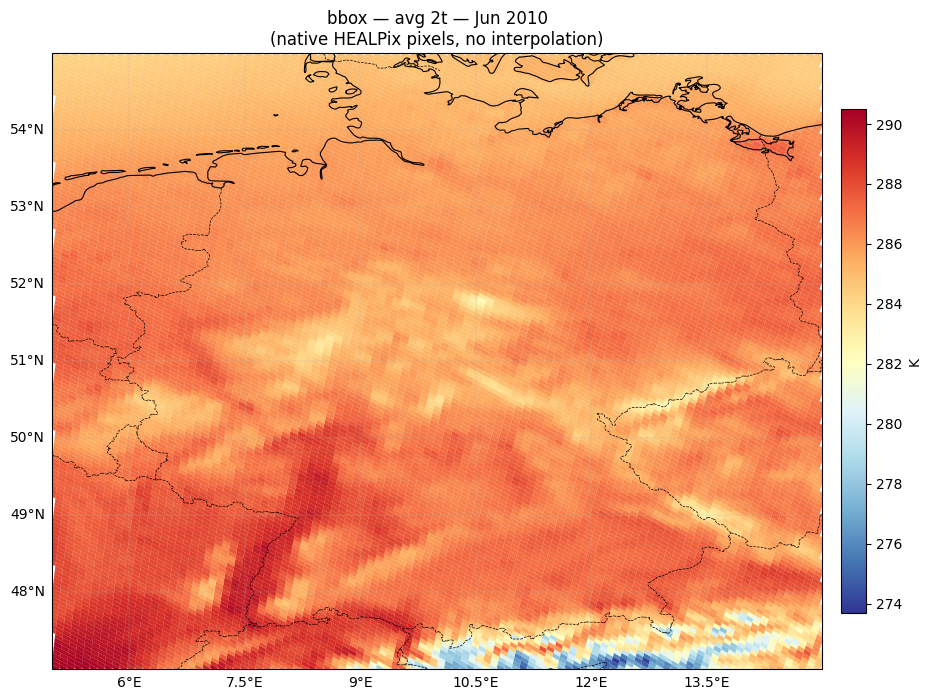

In [ ]:
# Plot with cartopy — native HEALPix cells, no interpolation
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(10, 7))

vmin, vmax = np.nanmin(values), np.nanmax(values)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.RdYlBu_r

coll = PolyCollection(polygons, transform=ccrs.PlateCarree(),
                       edgecolors="face", linewidths=0.1)
coll.set_array(values)
coll.set_cmap(cmap)
coll.set_norm(norm)
ax.add_collection(coll)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle="--")
ax.set_extent([5, 15, 47, 55])
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.colorbar(coll, ax=ax, label="K", shrink=0.8, pad=0.02)
ax.set_title("bbox — avg 2t — Jun 2010\n(native HEALPix pixels, no interpolation)")
plt.tight_layout()
plt.show()

## Feature extraction — polygon (country cut-out)

Uses `earthkit.geo.cartography.country_polygons()` to get the boundary
of any named country, then passes it to the Polytope polygon feature.
Returns native HEALPix cells inside the country shape — no interpolation.

> **See also:** [climate-dt-earthkit-fe-polygon.ipynb](../feature-extraction/climate-dt-earthkit-fe-polygon.ipynb) · [climate-dt-earthkit-fe-country.ipynb](../feature-extraction/climate-dt-earthkit-fe-country.ipynb) · [climate-dt-earthkit-fe-pcolormesh.ipynb](../feature-extraction/climate-dt-earthkit-fe-pcolormesh.ipynb)

In [ ]:
import earthkit.geo.cartography

# Get country boundary from Natural Earth via earthkit-geo
COUNTRY = "Germany"
shapes = earthkit.geo.cartography.country_polygons([COUNTRY], resolution=50e6)

poly_result = ds_high["avg_2t"].polytope.sel(
    model="IFS-FESOM",
    time="2010-06",
    polygon=shapes,
)

In [ ]:
print(f"{COUNTRY}: {len(shapes)} sub-polygon(s), {sum(len(s) for s in shapes)} vertices total")
print(type(poly_result))
poly_result

Germany: 6 sub-polygon(s), 562 vertices total
<class 'xarray.core.dataset.Dataset'>


<xarray.Dataset> Size: 352kB
Dimensions:    (time: 1, points: 8796)
Coordinates:
  * time       (time) datetime64[ns] 8B 2010-06-01
  * points     (points) int64 70kB 0 1 2 3 4 5 ... 8790 8791 8792 8793 8794 8795
    latitude   (points) float64 70kB 47.31 47.36 47.36 ... 54.87 54.87 54.87
    longitude  (points) float64 70kB 10.2 10.21 10.31 ... 8.738 8.857 8.976
    levelist   (points) float64 70kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    avg_2t     (time, points) float64 70kB 281.0 283.4 281.5 ... 285.0 285.0
Attributes: (12/16)
    activity:       baseline
    class:          d1
    dataset:        climate-dt
    experiment:     hist
    expver:         0001
    generation:     2
    ...             ...
    stream:         clmn
    type:           fc
    number:         0
    Forecast date:  2010-06-01T00:00:00Z
    step:           0
    date:           2010-06-01T00:00:00Z

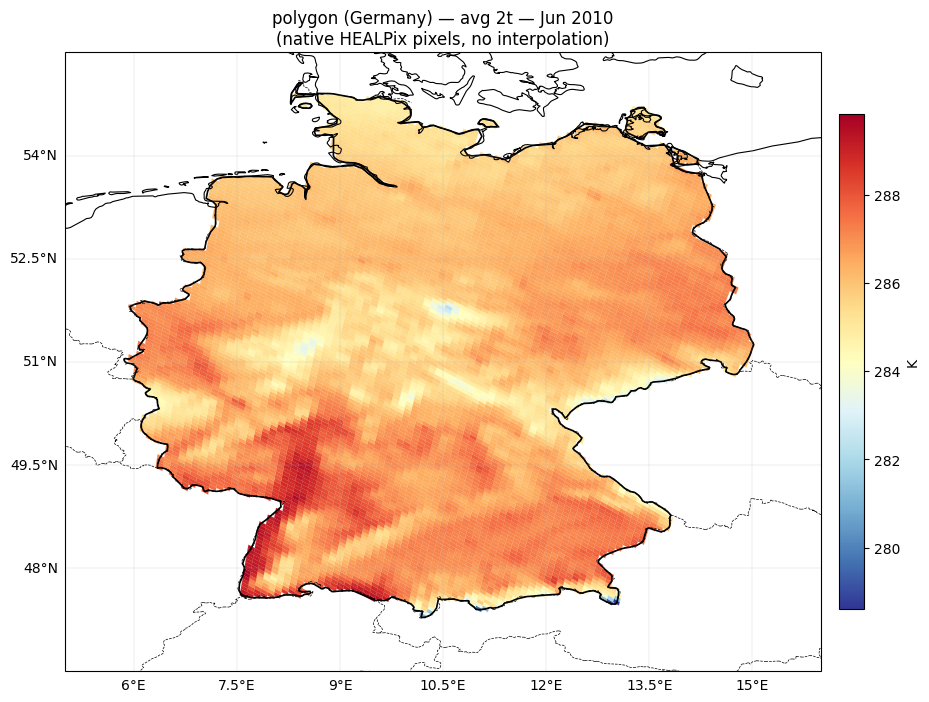

In [ ]:
nside = store_high.nside
da = poly_result["avg_2t"].squeeze()
lats = poly_result.coords["latitude"].values
lons = poly_result.coords["longitude"].values
values = da.values.ravel()

# HEALPix pixel indices (NESTED)
theta = np.radians(90.0 - lats)
phi = np.radians(lons)
pix_ids = hp.ang2pix(nside, theta, phi, nest=True)

n_steps = 50
boundaries = hp.boundaries(nside, pix_ids, step=n_steps, nest=True)

polygons = []
for i in range(len(pix_ids)):
    bx, by, bz = boundaries[i]
    b_lon = np.degrees(np.arctan2(by, bx))
    b_lat = np.degrees(np.arcsin(bz))
    polygons.append(list(zip(b_lon, b_lat)))

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(10, 7))

vmin, vmax = np.nanmin(values), np.nanmax(values)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

coll = PolyCollection(polygons, transform=ccrs.PlateCarree(),
                       edgecolors="face", linewidths=0.1)
coll.set_array(values)
coll.set_cmap(plt.cm.RdYlBu_r)
coll.set_norm(norm)
ax.add_collection(coll)

# Overlay country outline from earthkit-geo shapes
for shape in shapes:
    s_lons = [pt[1] for pt in shape]
    s_lats = [pt[0] for pt in shape]
    ax.plot(s_lons, s_lats, color="black", linewidth=1.2, transform=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle="--")
ax.set_extent([5, 16, 46.5, 55.5])
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.colorbar(coll, ax=ax, label="K", shrink=0.8, pad=0.02)
ax.set_title(f"polygon ({COUNTRY}) — avg 2t — Jun 2010\n(native HEALPix pixels, no interpolation)")
plt.tight_layout()
plt.show()

## Area subsetting with MARS keywords + server-side regridding

`area=(north, west, south, east)` returns data on a regular lat/lon grid (server-side interpolation).
Good choices are `grid="0.25/0.25"` for standard resolution and `grid="0.05/0.05"` for high-resolution data. You can use any other regular grid to control the output resolution.

> **See also:** [climate-dt-earthkit-area-example.ipynb](../full-field/climate-dt-earthkit-area-example.ipynb) · [climate-dt-earthkit-aoi-example.ipynb](../full-field/climate-dt-earthkit-aoi-example.ipynb) · [climate-dt-earthkit-serverside-interpolation.ipynb](../full-field-post-processing/climate-dt-earthkit-serverside-interpolation.ipynb)

In [ ]:
# Area subset over Central Europe — single month
area_ds = ds_high["avg_2t"].polytope.sel(
    model="IFS-FESOM",
    time="2010-06",
    area=(55, 5, 47, 15),   # (north, west, south, east)
    #grid="0.05/0.05",      # default for high resolution
)

In [ ]:
area_ds

<xarray.Dataset> Size: 262kB
Dimensions:    (latitude: 161, longitude: 201)
Coordinates:
  * latitude   (latitude) float64 1kB 55.0 54.95 54.9 54.85 ... 47.1 47.05 47.0
  * longitude  (longitude) float64 2kB 5.0 5.05 5.1 5.15 ... 14.9 14.95 15.0
Data variables:
    avg_2t     (latitude, longitude) float64 259kB ...
Attributes:
    param:        avg_2t
    paramId:      228004
    class:        d1
    stream:       clmn
    levtype:      sfc
    type:         fc
    expver:       0001
    date:         20100601
    Conventions:  CF-1.8
    institution:  ECMWF

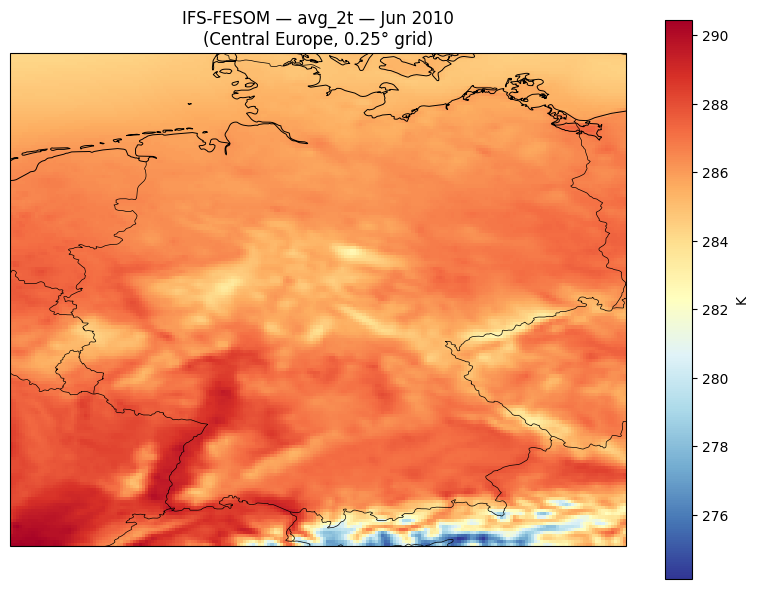

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

var_name = list(area_ds.data_vars)[0]
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(8, 6))
area_ds[var_name].plot(ax=ax, transform=ccrs.PlateCarree(), cmap="RdYlBu_r",
                       cbar_kwargs={"label": "K"})
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.set_title(f"IFS-FESOM — {var_name} — Jun 2010\n(Central Europe, 0.25° grid)")
plt.tight_layout()
plt.show()

## Notes for further use

- **Automatic batching:** use `.polytope.sel(time=slice(...))` to auto-batch Polytope requests over the requested year range. Regular `.sel()` fetches one year at a time (12 months per request).
- Try the other `LEVTYPES` as well in order to browse the full Climate DT portfolio, i.e. `o2d/o3d`, `pl/hl`, or `sol`
- `store.clear_cache()` frees memory from previously fetched fields.

In [ ]:
# Free memory if needed
store.clear_cache()
store_high.clear_cache()
scen_store.clear_cache()